# **Άσκηση 1**

Φόρτωση και εισαγωγή των Data από το Dateset του Zip αρχείου

In [3]:
import zipfile
import os
import cv2
import numpy as np

zip_path = '/content/Mask_DB.zip'

# Αποσυμπίεση του αρχείου ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

# Φόρτωση των εικόνων
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            images.append(img)
    return images

# Φόρτωση εικόνων από κάθε κατηγορία
without_mask = load_images_from_folder('/content/without_mask')
with_mask = load_images_from_folder('/content/with_mask')
mask_incorrect = load_images_from_folder('/content/mask_incorrect_use')

# Ετικέτες (0 = without_mask, 1 = with_mask, 2 = mask_incorrect)
labels_all = [0] * len(without_mask) + [1] * len(with_mask) + [2] * len(mask_incorrect)

# Συνδυασμός όλων των εικόνων
all_images = without_mask + with_mask + mask_incorrect

# Μετατροπή σε numpy arrays
all_images_np = np.array(all_images)
all_labels_np = np.array(labels_all)
print(f"Αριθμός εικόνων χωρίς μάσκα: {len(without_mask)}")
print(f"Αριθμός εικόνων με μάσκα: {len(with_mask)}")
print(f"Αριθμός εικόνων με λάθος χρήση μάσκας: {len(mask_incorrect)}")
print(f"Αριθμός όλων των εικόνων: {len(all_images)}")
print(f"Αριθμός όλων των labels: {len(labels_all)}")


Αριθμός εικόνων χωρίς μάσκα: 1044
Αριθμός εικόνων με μάσκα: 1044
Αριθμός εικόνων με λάθος χρήση μάσκας: 56
Αριθμός όλων των εικόνων: 2144
Αριθμός όλων των labels: 2144


**Ερώτημα Α.**

In [4]:
from sklearn.model_selection import train_test_split

images_a = with_mask + without_mask
labels_a = [0] * len(without_mask) + [1] * len(with_mask)

# Μετατροπή σε numpy arrays
images_np = np.array(images_a)
labels_np = np.array(labels_a)

# Διαχωρισμός σε σύνολα εκπαίδευσης, επικύρωσης και δοκιμής
train_images, test_val_images, train_labels, test_val_labels = train_test_split(images_np, labels_np, test_size=0.4, random_state=42)
val_images, test_images, val_labels, test_labels = train_test_split(test_val_images, test_val_labels, test_size=0.5, random_state=42)

total_images = len(images_a)
print(f"Ποσοστό εικόνων εκπαίδευσης: {len(train_images) / total_images * 100:.2f}%")
print(f"Ποσοστό εικόνων επικύρωσης: {len(val_images) / total_images * 100:.2f}%")
print(f"Ποσοστό εικόνων δοκιμής: {len(test_images) / total_images * 100:.2f}%")

Ποσοστό εικόνων εκπαίδευσης: 59.96%
Ποσοστό εικόνων επικύρωσης: 20.02%
Ποσοστό εικόνων δοκιμής: 20.02%


**Ερώτημα Β.**

Προεπεξεργασία και Resizing των εικόνων, προτού προχωρήσουμε με το νευρωνικό δίκτυο

In [65]:
import tensorflow as tf

# Ορίζουμε τις διαστάσεις της εικόνας εισόδου
height = 64
width = 64
channels = 3  # Τρία κανάλια για εικόνες RGB

# Συνάρτηση για την προεπεξεργασία των εικόνων
def preprocess_images(image_set):
    processed_images = []
    for img in image_set:
        # Μετατροπή σε float32 και κανονικοποίηση
        img = img.astype('float32') / 255.0
        # Resizing της εικόνας
        img = tf.image.resize(img, [height, width])
        processed_images.append(img)
    return np.array(processed_images)

# Προεπεξεργασία των συνόλων δεδομένων
train_images_preprocessed = preprocess_images(train_images)
val_images_preprocessed = preprocess_images(val_images)
test_images_preprocessed = preprocess_images(test_images)
mask_incorrect_use_preprocessed = preprocess_images(mask_incorrect)


Υλοποίηση Νευρωνικού Δικτύου

In [5]:
!pip show tensorflow
!pip show keras

# για εγκατάσταση/αναβάθμιση
!pip install tensorflow --upgrade
!pip install keras --upgrade


Name: tensorflow
Version: 2.15.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.10/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, setuptools, six, tensorboard, tensorflow-estimator, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine-rl
Name: keras
Version: 2.15.0
Summary: Deep learning for humans.
Home-page: https://keras.io/
Author: Keras team
Author-email: keras-users@googlegroups.com
License: Apache 2.0
Location: /usr/local/lib/python3.10/dist-packages
Requires: 
Required-by: tensorflow
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 1.3 MB/s eta 0:00:00
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.15.0
    U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 7.3 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.15.0.post1 requires keras<2.16,>=2.15.0, but you have keras 3.0.4 which is incompatible.


In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense

model = Sequential()
# Πρώτο συνελικτικό επίπεδο
model.add(Conv2D(32, (3, 3), input_shape=(height, width, channels)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Δεύτερο συνελικτικό επίπεδο
model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Τρίτο συνελικτικό επίπεδο
model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Πλήρως συνδεδεμένο επίπεδο
model.add(Flatten())  # Αυτό μετατρέπει τους 3D χάρτες χαρακτηριστικών σε 1D διάνυσμα
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(3))
model.add(Activation('softmax'))  # Για πολυκλαδική ταξινόμηση

# Συναρμολόγηση του μοντέλου
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.fit(train_images_preprocessed, train_labels, batch_size=32, epochs=10, validation_data=(val_images_preprocessed, val_labels))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step - accuracy: 0.7164 - loss: 0.6093 - val_accuracy: 0.8517 - val_loss: 0.4038
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.9462 - loss: 0.1815 - val_accuracy: 0.9522 - val_loss: 0.1550
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 179ms/step - accuracy: 0.9643 - loss: 0.1262 - val_accuracy: 0.9665 - val_loss: 0.1084
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.9683 - loss: 0.1155 - val_accuracy: 0.9761 - val_loss: 0.0783
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - accuracy: 0.9787 - loss: 0.0803 - val_accuracy: 0.9737 - val_loss: 0.0852
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.9687 - loss: 0.0982 - val_accuracy: 0.9737 - val_loss: 0.0933
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step - accuracy: 0.9828 - loss: 0.0834 - val_accuracy: 0.9785 - val_loss: 0.0814
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.9768 - loss: 0.0714 - val_accuracy: 0

**Ερώτημα Γ.**

In [37]:
!pip install -q -U keras-tuner

Reloading Tuner from my_dir/intro_to_kt/tuner0.json
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9757 - loss: 0.1160
Τελική απώλεια στο σύνολο δοκιμής (Test Loss): 0.1188
Τελική ακρίβεια στο σύνολο δοκιμής (Test Accuracy): 0.9713


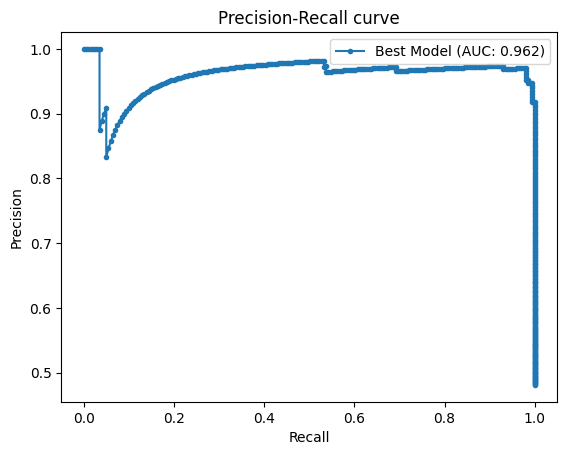

In [75]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
import kerastuner as kt
import tensorflow as tf


def build_model(hp):
    model = Sequential()
    # Πρώτο συνελικτικό επίπεδο
    model.add(Conv2D(hp.Int('conv_1_filter', min_value=32, max_value=128, step=16),
                     (3, 3),
                     input_shape=(height, width, channels)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Δεύτερο συνελικτικό επίπεδο
    model.add(Conv2D(hp.Int('conv_2_filter', min_value=32, max_value=64, step=16),
                     (3, 3)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Τρίτο συνελικτικό επίπεδο
    model.add(Conv2D(hp.Int('conv_3_filter', min_value=64, max_value=128, step=16),
                     (3, 3)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(hp.Int('dense_1_units', min_value=32, max_value=128, step=16)))
    model.add(Activation('relu'))
    model.add(Dropout(0.5))
    model.add(Dense(3))
    model.add(Activation('softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=10,
                     factor=3,
                     directory='my_dir',
                     project_name='intro_to_kt')

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

tuner.search(train_images_preprocessed, train_labels,
             epochs=50,
             validation_data=(val_images_preprocessed, val_labels),
             callbacks=[stop_early])

# Λήψη του βέλτιστου μοντέλου.
best_model = tuner.get_best_models(num_models=1)[0]
test_predictions = best_model.predict(test_images_preprocessed)

# Αξιολόγηση του βέλτιστου μοντέλου στο σύνολο δοκιμής
loss, accuracy = best_model.evaluate(test_images_preprocessed, test_labels)
print(f'Τελική απώλεια στο σύνολο δοκιμής (Test Loss): {loss:.4f}')
print(f'Τελική ακρίβεια στο σύνολο δοκιμής (Test Accuracy): {accuracy:.4f}')

precision, recall, _ = precision_recall_curve(test_labels, test_predictions[:, 1])
auc_score = auc(recall, precision)

# plotting
plt.figure()
plt.plot(recall, precision, marker='.', label=f'Best Model (AUC: {auc_score:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.title('Precision-Recall curve')
plt.show()


Προβολή των καλύτερων αποτελεσμάτων-συνδυασμών υπερπαραμέτρων από την παραπάνω αναζήτηση.

In [76]:
import kerastuner as kt
import tensorflow as tf

# Λήψη των βέλτιστων υπερπαραμέτρων
best_hyperparams = tuner.get_best_hyperparameters(num_trials=1)[0]

# Εκτύπωση των βέλτιστων υπερπαραμέτρων
print("Βέλτιστες υπερπαράμετροι:")
print(f"conv_1_filter: {best_hyperparams.get('conv_1_filter')}")
print(f"conv_2_filter: {best_hyperparams.get('conv_2_filter')}")
print(f"conv_3_filter: {best_hyperparams.get('conv_3_filter')}")
print(f"dense_1_units: {best_hyperparams.get('dense_1_units')}")


tuner.results_summary()

Βέλτιστες υπερπαράμετροι:
conv_1_filter: 48
conv_2_filter: 64
conv_3_filter: 128
dense_1_units: 32
Results summary
Results in my_dir/intro_to_kt
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0027 summary
Hyperparameters:
conv_1_filter: 48
conv_2_filter: 64
conv_3_filter: 128
dense_1_units: 32
tuner/epochs: 10
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.9832535982131958

Trial 0024 summary
Hyperparameters:
conv_1_filter: 128
conv_2_filter: 64
conv_3_filter: 64
dense_1_units: 32
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0022
Score: 0.9832535982131958

Trial 0028 summary
Hyperparameters:
conv_1_filter: 64
conv_2_filter: 64
conv_3_filter: 80
dense_1_units: 32
tuner/epochs: 10
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.9832535982131958

Trial 0017 summary
Hyperparameters:
conv_1_filter: 128
conv_2_filter: 64
conv_3_filter: 128
dense_1_units: 48
tuner/epochs: 10
tuner/initia

**Ερώτημα Δ.**

In [68]:
# Προβλέψεις του μοντέλου για τις εικόνες 'mask_incorrect_use'
predictions = model.predict(mask_incorrect_use_preprocessed)

# Οι προβλέψεις θα είναι σε μορφή πιθανοτήτων για κάθε κλάση, οπότε παίρνουμε την κλάση με την υψηλότερη πιθανότητα
predicted_classes = np.argmax(predictions, axis=1)

# οι κλάσεις είναι: 0 για 'without_mask', 1 για 'with_mask', και 2 για 'mask_incorrect_use'
# Υπολογίζουμε το ποσοστό των εικόνων που ταξινομήθηκαν λανθασμένα ως 'with_mask'
incorrectly_classified_as_correct = np.sum(predicted_classes == 1)
total_incorrect_mask_use_images = mask_incorrect_use_preprocessed.shape[0]
percentage_incorrectly_classified = (incorrectly_classified_as_correct / total_incorrect_mask_use_images) * 100

print(f"Ποσοστό εικόνων 'mask_incorrect_use' που ταξινομήθηκαν εσφαλμένα ως 'with_mask': {percentage_incorrectly_classified:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Ποσοστό εικόνων 'mask_incorrect_use' που ταξινομήθηκαν εσφαλμένα ως 'with_mask': 14.29%


Βελτιστοποίηση με anomaly detection

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# μοντέλο
model = Sequential()
model.add(Flatten(input_shape=(64, 64, 3)))  # Μετατρέπουμε τις εικόνες σε 1D διάνυσμα
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # Δυαδική κατάσταση: κανονική ή ανώμαλη

# μοντέλο
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# ετικέτες σε δυαδική μορφή: 0 για "without_mask", 1 για "with_mask"
binary_train_labels = (train_labels > 0).astype(int)
binary_val_labels = (val_labels > 0).astype(int)

# Εκπαιδεύουμε το μοντέλο
model.fit(train_images_preprocessed, binary_train_labels, epochs=10, validation_data=(val_images_preprocessed, binary_val_labels))

# Προβλέψεις στο σετ 'mask_incorrect_use'
predictions = model.predict(mask_incorrect_use_preprocessed)
anomaly_scores = predictions.flatten()  # Μετατρέπουμε τις προβλέψεις σε 1D διάνυσμα για ανάλυση
anomalies = anomaly_scores > 0.0005  # Θέτουμε ένα κατώφλι για τον εντοπισμό ανωμαλιών

# Υπολογίζουμε το ποσοστό των εικόνων που ταξινομούνται ως ανωμαλίες
percentage_anomalies = np.mean(anomalies) * 100
print(f"Ποσοστό των εικόνων 'mask_incorrect_use' που ταξινομήθηκαν ως anomalies: {percentage_anomalies:.2f}%")

# Υπολογισμός του ποσοστού των εικόνων 'mask_incorrect_use' που ταξινομήθηκαν εσφαλμένα ως 'with_mask'
mask_incorrect_use_predicted_as_with_mask = np.sum(anomaly_scores < 0.0005)  # Χρησιμοποιούμε το αντίθετο κατώφλι αφού οι κανονικές κλάσεις είναι 0 και 1
percentage_incorrect_use_as_with_mask = (mask_incorrect_use_predicted_as_with_mask / len(mask_incorrect_use_preprocessed)) * 100

print(f"Ποσοστό των εικόνων 'mask_incorrect_use' που ταξινομήθηκαν εσφαλμένα ως 'with_mask': {percentage_incorrect_use_as_with_mask:.2f}%")



Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5581 - loss: 2.0744 - val_accuracy: 0.7879 - val_loss: 0.4637
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7336 - loss: 0.5235 - val_accuracy: 0.9219 - val_loss: 0.2899
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8070 - loss: 0.4158 - val_accuracy: 0.8929 - val_loss: 0.2536
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8529 - loss: 0.3950 - val_accuracy: 0.9531 - val_loss: 0.2439
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8506 - loss: 0.3493 - val_accuracy: 0.9732 - val_loss: 0.1595
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8078 - loss: 0.3955 - val_accuracy: 0.9710 - val_loss: 0.1054
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8653 - loss: 0.3326 - val_accuracy: 0.9554 - val_loss: 0.1435
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8203 - loss: 0.3290 - val_accuracy: 0.9643 - v